# Exploration Data Analysis

The first part of the project has the aim to run the **complete exploratory analysis** of the datasets. In particular, after loading both of them with the *NetworkX* package from *Python*, it would be verified the **class imbalance**, computing the percentage of positive and negative edges.

While the *soc-sign-bitcoinotc* dataset was already sorted by timestamp, the same did not hold for *soc-sign-bitcoinalpha*. To ensure consistency, both datasets were programmatically sorted by timestamp before being split into training (oldest 80%) and test (most recent 20%) sets.

In the end, the **degree distribution** would be computed with the plot of log-log graphs and the final **computation of reciprocity rate, fraction of signed edges by direction and triad census** will be computed.

## Dataset Loading & Parsing

In [ ]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

To let the code find correctly the datasets **one** of the following ways has to be followed:

*   load in the *Files* folder of the notebook the two datasets (Bitcoin Alpha and Bitcoin OTC) downloaded from [link](https://snap.stanford.edu/data/);
*   uncomment the lines with `!wget` and `!gunzip`


In [ ]:
!wget https://snap.stanford.edu/data/soc-sign-bitcoinalpha.csv.gz
!wget https://snap.stanford.edu/data/soc-sign-bitcoinotc.csv.gz
!gunzip -f soc-sign-bitcoinalpha.csv.gz soc-sign-bitcoinotc.csv.gz

#load of the CSV (SOURCE, TARGET, RATING, TIME)
alpha = pd.read_csv('soc-sign-bitcoinalpha.csv',
                    names=['source','target','rating','time'])
otc   = pd.read_csv('soc-sign-bitcoinotc.csv',
                    names=['source','target','rating','time'])

#parsing of the timestamsp
for df in [alpha, otc]:
    df['datetime'] = pd.to_datetime(df['time'], unit='s')

# Derive binary sign labels: +1 if rating > 0, -1 otherwise
for df in [alpha, otc]:
    df['sign'] = df['rating'].apply(lambda x: 1 if x > 0 else -1) #application of lambda function

# for the weights it is used the absolute value
for df in [alpha, otc]:
    df['weight'] = df['rating'].abs()



--2026-06-05 13:05:01--  https://snap.stanford.edu/data/soc-sign-bitcoinalpha.csv.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 149480 (146K) [application/x-gzip]
Saving to: ‘soc-sign-bitcoinalpha.csv.gz’

soc-sign-bitcoinalp 100%[===================>] 145.98K   369KB/s    in 0.4s    

2026-06-05 13:05:02 (369 KB/s) - ‘soc-sign-bitcoinalpha.csv.gz’ saved [149480/149480]

--2026-06-05 13:05:02--  https://snap.stanford.edu/data/soc-sign-bitcoinotc.csv.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 397258 (388K) [application/x-gzip]
Saving to: ‘soc-sign-bitcoinotc.csv.gz’

soc-sign-bitcoinotc 100%[===================>] 387.95K   486KB/s    in 0.8s    

2026-06-05 13:05:03 (48

## Class Imbalance

To compute the class imbalance for both datasets, a `for` loop is used. For each dataset, the number of positive and negative edges is counted, and the class imbalance is measured by computing the percentage of positive and negative edges.

In [ ]:
for name, df in [('Alpha', alpha), ('OTC', otc)]:
  tot = len(df)
  print(f"{name}: {(df['rating'] > 0).sum()/tot:.1%} positive edges, {(df['rating'] < 0).sum()/tot:.1%} negative edges")

Alpha: 93.6% positive edges, 6.4% negative edges
OTC: 90.0% positive edges, 10.0% negative edges


## Temporal Sort + 80/20 split


In [ ]:
def temporal_split(df, train_ratio=0.8):
    df_sorted = df.sort_values('time').reset_index(drop=True) #using field time that has been parsed before
    split_idx = int(len(df_sorted) * train_ratio)
    train = df_sorted.iloc[:split_idx]
    test  = df_sorted.iloc[split_idx:]
    return train, test

alpha_train, alpha_test = temporal_split(alpha)
otc_train,   otc_test   = temporal_split(otc)

print(f"Alpha train: {len(alpha_train)}, test: {len(alpha_test)}")
print(f"OTC   train: {len(otc_train)},   test: {len(otc_test)}")

Alpha train: 19348, test: 4838
OTC   train: 28473,   test: 7119


The following code is a **unit test** to verify that no future leakage occurs.

We do this **to ensure scientifically valid results**; in particular, in a real deployment, we would not have access to ratings that have not happened yet. Leakage is easy to introduce accidentally when working with datasets that have timestamps and hard to notice without explicitly checking your implementation.

In [ ]:
def test_no_leakage(train, test, name):
    max_train_time = train['time'].max()
    min_test_time  = test['time'].min()
    assert min_test_time >= max_train_time, \
        f"LEAKAGE in {name}: the set of the testing has edges before the end of the training phase!"
    print(f"{name}: no leakage (max train={max_train_time}, min test={min_test_time}), everything is correct")

test_no_leakage(alpha_train, alpha_test, 'Alpha')
test_no_leakage(otc_train,   otc_test,   'OTC')

Alpha: no leakage (max train=1376366400, min test=1376366400), everything is correct
OTC: no leakage (max train=1382719445.44488, min test=1382721422.92466), everything is correct


## Graph Construction

For the graph construction, as  previously said, the *NetworkX* package is used, in particular *DiGraph()* function. Every edge of the graph will have 4 features encapsulated:


* rating
* sign (based on the previous parsing)
* weight (based on the previous parsing)
* time





In [ ]:
#creation of the graphs using networkx
def build_graph(df):
    G = nx.DiGraph() #creates an empty graph structure (a “null graph”) with no nodes and no edges.
    for _, row in df.iterrows():
        G.add_edge(row['source'], row['target'],
                   rating=row['rating'],
                   sign=row['sign'],
                   weight=row['weight'],
                   time=row['time'])
    return G


#only the train datasets are used as graphs to prevent data leakage, ensuring no
#future edge information influences the structural features used for prediction.
G_alpha = build_graph(alpha_train)
G_otc   = build_graph(otc_train)

## Degree distribution and log-log graph

The degree distribution is computed for both graphs and concerns simply the calculation of the in-degree (incoming edges) and out-degree (outcoming edges) using the functions `in_degree()` and `out_degree()`.

Then the log-log diagram of both graphs is plotted.  

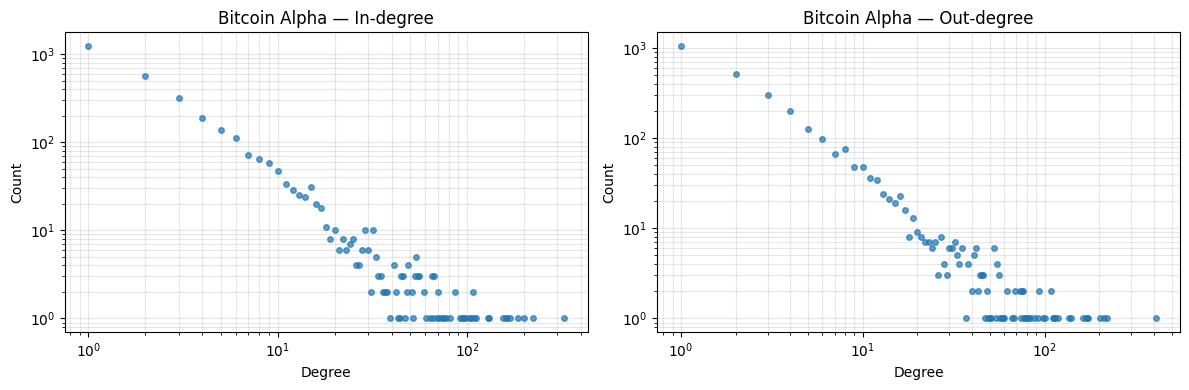

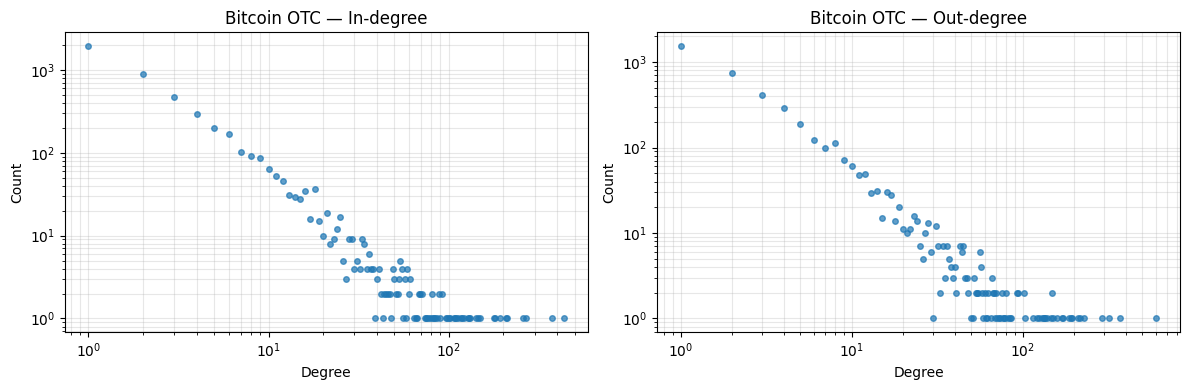

In [ ]:
def plot_degree_distribution(G, name):
    in_deg  = [d for _, d in G.in_degree()]
    out_deg = [d for _, d in G.out_degree()]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, degrees, label in zip(axes, [in_deg, out_deg], ['In-degree', 'Out-degree']):
        counts = np.bincount(degrees)
        deg_vals = np.nonzero(counts)[0]
        ax.loglog(deg_vals, counts[deg_vals], 'o', markersize=4, alpha=0.7)
        ax.set_xlabel('Degree')
        ax.set_ylabel('Count')
        ax.set_title(f'{name} — {label}')
        ax.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{name.lower()}_degree_dist.png', dpi=150)
    plt.show()

plot_degree_distribution(G_alpha, 'Bitcoin Alpha')
plot_degree_distribution(G_otc,   'Bitcoin OTC')

## Reciprocity Rate and Fraction of Signed Edges
To better conduct the structural analysis of the signed graphs, it is useful to calculate:
* How many links are reciprocal: the **reciprocity** can be directly calculated using the `reciprocity()` function from *NetworkX*. It returns a value between 0 and 1, where 0 means no edge is reciprocated and 1 means every edge has a return edge.

  It represents how much the network is **bidirectional/social**.

* What is the **sign** of the reciprocal edges

In [ ]:
def signed_edge_analysis(G, name):
    recip = nx.reciprocity(G)
    print(f"\n{name} — Reciprocity: {recip:.4f}")

    pos_uv_pos_vu = 0  # u→v is +, v→u is +
    pos_uv_neg_vu = 0  # u→v is +, v→u is -
    neg_uv_pos_vu = 0  # u→v is -, v→u is +
    neg_uv_neg_vu = 0  # u→v is -, v→u is -

    for u, v, d in G.edges(data=True):
        if G.has_edge(v, u):

            sign_uv = d['sign']
            sign_vu = G[v][u]['sign']

            if sign_uv == 1 and sign_vu == 1:
                pos_uv_pos_vu += 1
            elif sign_uv == 1 and sign_vu == -1:
                pos_uv_neg_vu += 1
            elif sign_uv == -1 and sign_vu == 1:
                neg_uv_pos_vu += 1
            else:
                neg_uv_neg_vu += 1

    total_recip = pos_uv_pos_vu + pos_uv_neg_vu + neg_uv_pos_vu + neg_uv_neg_vu

    if total_recip > 0:
        print(f"  Total reciprocated edges: {total_recip}")
        print(f"\n  u→v is POSITIVE:")
        pos_uv_total = pos_uv_pos_vu + pos_uv_neg_vu
        print(f"    v→u is also positive : {pos_uv_pos_vu} ({pos_uv_pos_vu/pos_uv_total:.1%})")
        print(f"    v→u is negative      : {pos_uv_neg_vu} ({pos_uv_neg_vu/pos_uv_total:.1%})")

        print(f"\n  u→v is NEGATIVE:")
        neg_uv_total = neg_uv_pos_vu + neg_uv_neg_vu
        if neg_uv_total > 0:
            print(f"    v→u is positive      : {neg_uv_pos_vu} ({neg_uv_pos_vu/neg_uv_total:.1%})")
            print(f"    v→u is also negative : {neg_uv_neg_vu} ({neg_uv_neg_vu/neg_uv_total:.1%})")
        else:
            print(f"    no reciprocated negative edges found")

signed_edge_analysis(G_alpha, 'Alpha')
signed_edge_analysis(G_otc,   'OTC')



Alpha — Reciprocity: 0.8499
  Total reciprocated edges: 16444

  u→v is POSITIVE:
    v→u is also positive : 15942 (99.0%)
    v→u is negative      : 159 (1.0%)

  u→v is NEGATIVE:
    v→u is positive      : 159 (46.4%)
    v→u is also negative : 184 (53.6%)

OTC — Reciprocity: 0.8051
  Total reciprocated edges: 22924

  u→v is POSITIVE:
    v→u is also positive : 21964 (98.8%)
    v→u is negative      : 265 (1.2%)

  u→v is NEGATIVE:
    v→u is positive      : 265 (38.1%)
    v→u is also negative : 430 (61.9%)


## Triad census

A triad census is a **count of how many of each triangle type exist in a graph**. For signed directed graphs, this
tells us **how much the network already conforms to the predictions of Balance Theory**.

**Overrepresentation of +++ and +−− triangles would be empirical evidence that Balance Theory actively shapes the network**, justifying the use of balance-theoretic features in a predictive model.

In [ ]:
def triad_census_signed(G, name):

    balanced   = 0
    unbalanced = 0
    nodes = list(G.nodes())

    for i, u in enumerate(nodes):
        neighbors_u = set(G.successors(u))
        for v in neighbors_u: # u->v --> loop for each neighbors of u
            neighbors_v = set(G.successors(v))
            common = neighbors_u & neighbors_v  # trianglular closure
            for w in common:
                if u == w or v == w:
                    continue
                # we get the signs of the three graphs
                s_uv = G[u][v]['sign']
                s_vw = G[v][w]['sign']
                s_uw = G[u][w]['sign']

                product = s_uv * s_vw * s_uw
                if product == 1: ## +++ +--
                    balanced += 1
                else:
                    unbalanced += 1

    total = balanced + unbalanced
    if total > 0:
        print(f"\n{name} — Triad Census found: {total}")
        print(f"  Balanced   : {balanced}  ({balanced/total:.1%})")
        print(f"  Unbalances : {unbalanced} ({unbalanced/total:.1%})")
    else:
        print(f"{name}: no triads found")

triad_census_signed(G_alpha, 'Alpha')
triad_census_signed(G_otc,   'OTC')


Alpha — Triad Census found: 49972
  Balanced   : 45489  (91.0%)
  Unbalances : 4483 (9.0%)

OTC — Triad Census found: 71020
  Balanced   : 64896  (91.4%)
  Unbalances : 6124 (8.6%)


## Tabulate and compare structural stats: OTC vs. Alpha (density, avg degree, clustering coeff.)

In [ ]:
def structural_stats(G, name):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    return {
        'Dataset': name,
        'Nodes': n,
        'Edges': m,
        'Density': round(nx.density(G), 6),
        'Avg Degree': round(m / n, 2),
        'Avg Clustering': round(nx.average_clustering(G), 4)
    }

G_alpha_full = nx.from_pandas_edgelist(alpha, 'source', 'target', create_using=nx.DiGraph())
G_otc_full   = nx.from_pandas_edgelist(otc,   'source', 'target', create_using=nx.DiGraph())

pd.DataFrame([
    structural_stats(G_alpha_full, 'Bitcoin Alpha'),
    structural_stats(G_otc_full,   'Bitcoin OTC')
]).set_index('Dataset')

,Nodes,Edges,Density,Avg Degree,Avg Clustering
Dataset,,,,,
Bitcoin Alpha,3783,24186,0.001690,6.39,0.1583
Bitcoin OTC,5881,35592,0.001029,6.05,0.1511


## Local Node Feature Engineering

We summarise **each node's past behaviour** as a rater and as a target. For example, has `u` been generous or harsh? Is `v` generally trusted?

These six features are computed per interaction using only historical data before that row's timestamp:

| Feature | Description |
|---|---|
| `u_out_degree` | How many ratings `u` has given |
| `u_mean_given` | Average score `u` assigns to others |
| `u_pos_frac` | Share of positive ratings `u` gives |
| `v_in_degree` | How many ratings `v` has received |
| `v_mean_received` | Average score `v` receives from others |
| `v_pos_frac` | Share of positive ratings `v` receives |

Note: `target` in the dataframe columns refers to the destination node ID. `y`, the ML label, is the `sign` column (+1 for trust, -1 for distrust), derived from `rating` earlier in the pipeline.

### `LocalNodeHistory`

A dynamic dictionary storing real-time node metrics, updated sequentially per interaction.

**For each row:** `get_features()` first (read the past), then `update()` (record the present). This order ensures the model never sees the current rating inside its own features.

**Memory is never reset between train and test** — a user with 500 past interactions should still look like a well-known user when the test set begins, not a stranger. Clearing the tracker at the boundary would throw away all the reputation signals the model just learned.

In [ ]:
from collections import defaultdict

class LocalNodeHistory:
    """
    Streaming accumulator for per-node rating statistics.

    Tracks each node in two roles:
      - SOURCE (u): ratings it has given
      - TARGET (v): ratings it has received

    Per edge, always: get_features() -> update()
    """

    def __init__(self):
        # source-side counters
        self.out_degree     = defaultdict(int)
        self.out_rating_sum = defaultdict(float)
        self.out_pos_count  = defaultdict(int)

        # target-side counters
        self.in_degree      = defaultdict(int)
        self.in_rating_sum  = defaultdict(float)
        self.in_pos_count   = defaultdict(int)

    def update(self, source, target, rating):
        """Update node history with the current interaction. Call after get_features()."""
        self.out_degree[source]     += 1
        self.out_rating_sum[source] += rating
        if rating > 0:
            self.out_pos_count[source] += 1

        self.in_degree[target]      += 1
        self.in_rating_sum[target]  += rating
        if rating > 0:
            self.in_pos_count[target] += 1

    def get_features(self, u, v):
        """
        Snapshot the current stats for candidate edge u -> v.
        Nodes with no history default to 0 / 0.0.
        """
        u_out_deg = self.out_degree[u]
        v_in_deg  = self.in_degree[v]

        u_mean_given = (
            self.out_rating_sum[u] / u_out_deg if u_out_deg > 0 else 0.0
        )
        v_mean_received = (
            self.in_rating_sum[v] / v_in_deg if v_in_deg > 0 else 0.0
        )
        u_pos_frac = (
            self.out_pos_count[u] / u_out_deg if u_out_deg > 0 else 0.0
        )
        v_pos_frac = (
            self.in_pos_count[v] / v_in_deg if v_in_deg > 0 else 0.0
        )

        return {
            'u_out_degree':    u_out_deg,
            'u_mean_given':    u_mean_given,
            'u_pos_frac':      u_pos_frac,
            'v_in_degree':     v_in_deg,
            'v_mean_received': v_mean_received,
            'v_pos_frac':      v_pos_frac,
        }

    def get_node_summary(self, node_id):
        """Quick inspection helper for a single node."""
        out_deg = self.out_degree[node_id]
        in_deg  = self.in_degree[node_id]
        return {
            'ratings_sent':     out_deg,
            'ratings_received': in_deg,
            'mean_score_sent':  self.out_rating_sum[node_id] / out_deg if out_deg > 0 else 0.0,
            'mean_score_recv':  self.in_rating_sum[node_id]  / in_deg  if in_deg  > 0 else 0.0,
            'pos_rate_sent':    self.out_pos_count[node_id]  / out_deg if out_deg > 0 else 0.0,
        }

### `get_node_features(u, v, t)`

The main function the pipeline calls to get features for a candidate edge. It just reads from `LocalNodeHistory`, which is created and managed by `build_feature_matrix`.

In [ ]:
def get_node_features(u, v, t, node_history):
    """
    Return the 6 local features for edge u -> v at time t.
    node_history must already contain all edges with timestamp < t.
    """
    return node_history.get_features(u, v)

### `build_feature_matrix`

Runs one pass over the data, first through the training set, then the test set, building features for every edge. `LocalNodeHistory` starts empty and grows with each row, so by the time we hit the test set it already knows everything from training. Returns two DataFrames (features only) and the live history object.

In [ ]:
def build_feature_matrix(train_df, test_df):
    """
    Single streaming pass over train -> test.

    For each row: extract features THEN update history.
    The node_history is never reset between splits.

    Returns

    train_features : pd.DataFrame  Shape (len(train_df), 6)
    test_features  : pd.DataFrame  Shape (len(test_df), 6)
    node_history   : LocalNodeHistory  Full history after all edges
    """
    node_history = LocalNodeHistory()
    train_rows   = []
    test_rows    = []

    for _, row in train_df.iterrows():
        features = get_node_features(row['source'], row['target'], row['time'], node_history)
        train_rows.append(features)
        node_history.update(row['source'], row['target'], row['rating'])

    for _, row in test_df.iterrows():
        features = get_node_features(row['source'], row['target'], row['time'], node_history)
        test_rows.append(features)
        node_history.update(row['source'], row['target'], row['rating'])

    train_features = pd.DataFrame(train_rows, index=train_df.index)
    test_features  = pd.DataFrame(test_rows,  index=test_df.index)

    return train_features, test_features, node_history

### Bitcoin Alpha

Alpha is smaller (~24k edges) so we validate here first before running on OTC.

In [ ]:
FEATURE_COLS = ['u_out_degree', 'u_mean_given', 'u_pos_frac',
                'v_in_degree',  'v_mean_received', 'v_pos_frac']

alpha_train_feats, alpha_test_feats, alpha_history = build_feature_matrix(alpha_train, alpha_test)

#  X / y split
# 'target' column = node ID
# 'rating' column = ML label (y)
X_train_alpha = alpha_train_feats[FEATURE_COLS]
y_train_alpha = alpha_train['sign'].values

X_test_alpha  = alpha_test_feats[FEATURE_COLS]
y_test_alpha  = alpha_test['sign'].values

print('Alpha X_train:', X_train_alpha.shape, '  y_train:', y_train_alpha.shape)
print('Alpha X_test: ', X_test_alpha.shape,  '  y_test: ', y_test_alpha.shape)
print()
print(X_train_alpha.describe().round(3))


print('\n X_train_alpha (first 10 rows)')
print(X_train_alpha.head(10).to_string())

print('\n y_train_alpha (first 10 values)')
print(y_train_alpha[:10])

print('\n X_test_alpha (first 10 rows)')
print(X_test_alpha.head(10).to_string())

print('\n y_test_alpha (first 10 values)')
print(y_test_alpha[:10])


Alpha X_train: (19348, 6)   y_train: (19348,)
Alpha X_test:  (4838, 6)   y_test:  (4838,)

       u_out_degree  u_mean_given  u_pos_frac  v_in_degree  v_mean_received  \
count     19348.000     19348.000   19348.000    19348.000        19348.000   
mean         23.945         1.333       0.823       20.793            1.364   
std          44.991         1.344       0.356       37.222            1.473   
min           0.000       -10.000       0.000        0.000          -10.000   
25%           2.000         0.966       0.917        1.000            1.000   
50%           7.000         1.222       1.000        6.000            1.406   
75%          26.000         1.812       1.000       23.000            1.994   
max         410.000        10.000       1.000      323.000           10.000   

       v_pos_frac  
count   19348.000  
mean        0.815  
std         0.378  
min         0.000  
25%         0.983  
50%         1.000  
75%         1.000  
max         1.000  

 X_train_alpha (

#### Create alpha csv for sanity-checking -->  `processed_alpha.csv`

Metadata columns (source, target node IDs, time) joined with the 6 features and the rating label. Useful for sanity-checking individual rows. GO TO'FILES' IN GOOGLE COLAB TO TAKE A LOOK.

In [ ]:
# Merge metadata + features + label for auditing
alpha_train_master = alpha_train[['source', 'target', 'time', 'rating', 'sign']].copy()
alpha_train_master = alpha_train_master.join(alpha_train_feats[FEATURE_COLS])
alpha_train_master['split'] = 'train'

alpha_test_master = alpha_test[['source', 'target', 'time', 'rating', 'sign']].copy()
alpha_test_master = alpha_test_master.join(alpha_test_feats[FEATURE_COLS])
alpha_test_master['split'] = 'test'

processed_alpha = pd.concat([alpha_train_master, alpha_test_master]).reset_index(drop=True)
processed_alpha.to_csv('processed_alpha.csv', index=False)

print('processed_alpha.csv saved:', processed_alpha.shape)
print(processed_alpha.head(5).to_string())

processed_alpha.csv saved: (24186, 12)
   source  target        time  rating  sign  u_out_degree  u_mean_given  u_pos_frac  v_in_degree  v_mean_received  v_pos_frac  split
0      10     271  1289192400       8     1             0           0.0         0.0            0              0.0         0.0  train
1      10     970  1289192400       8     1             1           8.0         1.0            0              0.0         0.0  train
2     113      54  1289192400       4     1             0           0.0         0.0            0              0.0         0.0  train
3       2     402  1289192400       1     1             0           0.0         0.0            0              0.0         0.0  train
4     119     471  1289365200       9     1             0           0.0         0.0            0              0.0         0.0  train


### Bitcoin OTC

Same logic, just swap the DataFrames.

In [ ]:
otc_train_feats, otc_test_feats, otc_history = build_feature_matrix(otc_train, otc_test)

X_train_otc = otc_train_feats[FEATURE_COLS]
y_train_otc = otc_train['sign'].values

X_test_otc  = otc_test_feats[FEATURE_COLS]
y_test_otc  = otc_test['sign'].values

print('OTC X_train:', X_train_otc.shape, '  y_train:', y_train_otc.shape)
print('OTC X_test: ', X_test_otc.shape,  '  y_test: ', y_test_otc.shape)
print()
print(X_train_otc.describe().round(3))


print('\n X_train_alpha (first 10 rows)')
print(X_train_otc.head(10).to_string())

print('\n y_train_alpha (first 10 values)')
print(y_train_otc[:10])

print('\n X_test_alpha (first 10 rows)')
print(X_test_otc.head(10).to_string())

print('\n y_test_alpha (first 10 values)')
print(y_test_otc[:10])


OTC X_train: (28473, 6)   y_train: (28473,)
OTC X_test:  (7119, 6)   y_test:  (7119,)

       u_out_degree  u_mean_given  u_pos_frac  v_in_degree  v_mean_received  \
count     28473.000     28473.000   28473.000    28473.000        28473.000   
mean         31.692         1.027       0.796       24.595            1.155   
std          65.793         2.028       0.367       49.581            1.862   
min           0.000       -10.000       0.000        0.000          -10.000   
25%           2.000         0.429       0.857        1.000            1.000   
50%           8.000         1.125       1.000        6.000            1.333   
75%          30.000         1.714       1.000       24.000            1.919   
max         604.000        10.000       1.000      434.000           10.000   

       v_pos_frac  
count   28473.000  
mean        0.791  
std         0.388  
min         0.000  
25%         0.917  
50%         1.000  
75%         1.000  
max         1.000  

 X_train_alpha (firs

#### Create otc csv for sanity-checking --> `processed_otc.csv`

In [ ]:
otc_train_master = otc_train[['source', 'target', 'time', 'rating', 'sign']].copy()
otc_train_master = otc_train_master.join(otc_train_feats[FEATURE_COLS])
otc_train_master['split'] = 'train'

otc_test_master = otc_test[['source', 'target', 'time', 'rating', 'sign']].copy()
otc_test_master = otc_test_master.join(otc_test_feats[FEATURE_COLS])
otc_test_master['split'] = 'test'

processed_otc = pd.concat([otc_train_master, otc_test_master]).reset_index(drop=True)
processed_otc.to_csv('processed_otc.csv', index=False)

print('processed_otc.csv saved:', processed_otc.shape)
print(processed_otc.head(5).to_string())

processed_otc.csv saved: (35592, 12)
   source  target          time  rating  sign  u_out_degree  u_mean_given  u_pos_frac  v_in_degree  v_mean_received  v_pos_frac  split
0       6       2  1.289242e+09       4     1             0           0.0         0.0            0              0.0         0.0  train
1       6       5  1.289242e+09       2     1             1           4.0         1.0            0              0.0         0.0  train
2       1      15  1.289243e+09       1     1             0           0.0         0.0            0              0.0         0.0  train
3       4       3  1.289245e+09       7     1             0           0.0         0.0            0              0.0         0.0  train
4      13      16  1.289254e+09       8     1             0           0.0         0.0            0              0.0         0.0  train


In [ ]:
print('=== Alpha ===')
print(f'  X_train_alpha : {X_train_alpha.shape}')
print(f'  y_train_alpha : {y_train_alpha.shape}')
print(f'  X_test_alpha  : {X_test_alpha.shape}')
print(f'  y_test_alpha  : {y_test_alpha.shape}')
print()
print('=== OTC ===')
print(f'  X_train_otc   : {X_train_otc.shape}')
print(f'  y_train_otc   : {y_train_otc.shape}')
print(f'  X_test_otc    : {X_test_otc.shape}')
print(f'  y_test_otc    : {y_test_otc.shape}')

=== Alpha ===
  X_train_alpha : (19348, 6)
  y_train_alpha : (19348,)
  X_test_alpha  : (4838, 6)
  y_test_alpha  : (4838,)

=== OTC ===
  X_train_otc   : (28473, 6)
  y_train_otc   : (28473,)
  X_test_otc    : (7119, 6)
  y_test_otc    : (7119,)


# Structural Features


Balance Theory Featues

In [ ]:
from collections import defaultdict

class StreamingSignedGraph:
    """
    Streaming signed directed graph that grows as edges arrive.
    Stores adjacency in both directions so we can quickly find,
    for any candidate edge u -> v, the common neighbours w with
    u -> w AND w -> v already present.

    Used to compute Balance Theory features WITHOUT data leakage:
    we only ever look at edges added before the current row.
    """

    def __init__(self):
        # out_edges[u][v] = sign of edge u -> v
        self.out_edges = defaultdict(dict)
        # in_edges[v][u] = sign of edge u -> v
        self.in_edges  = defaultdict(dict)

    def add_edge(self, u, v, sign):
        self.out_edges[u][v] = sign
        self.in_edges[v][u]  = sign

    def balance_features(self, u, v):
        """
        For candidate edge u -> v, look at every common neighbour w
        such that u -> w and w -> v already exist in the graph.

        For each such w, Balance Theory says the triad (u, v, w) is
        balanced iff   sign(u->w) * sign(w->v) * sign(u->v) = +1.
        Without observing sign(u->v), the implied sign is
            s_pred = sign(u->w) * sign(w->v).
        We summarise the distribution of s_pred across all common
        neighbours: this is leakage-free and ready to feed an ML model.
        """
        u_out = self.out_edges.get(u, {})
        v_in  = self.in_edges.get(v,  {})
        if len(u_out) <= len(v_in):
            cand, other = u_out.keys(), v_in
        else:
            cand, other = v_in.keys(), u_out
        n_total = 0
        n_pos   = 0
        for w in cand:
            if w == u or w == v or w not in other:
                continue
            s_uw = u_out[w]
            s_wv = v_in[w]
            n_total += 1
            if s_uw * s_wv == 1:
                n_pos += 1
        n_neg = n_total - n_pos
        # frac_balance_pred_pos: fraction of common neighbours whose
        # two-edge product = +1, i.e. that "vote" for u->v being +.
        frac_pos       = (n_pos / n_total) if n_total > 0 else 0.0
        # balance_signal in [-1, +1]: net vote of common neighbours.
        balance_signal = ((n_pos - n_neg) / n_total) if n_total > 0 else 0.0
        return {
            'n_common_neighbors':    n_total,
            'n_balance_pred_pos':    n_pos,
            'n_balance_pred_neg':    n_neg,
            'frac_balance_pred_pos': frac_pos,
            'balance_signal':        balance_signal,
        }


BALANCE_FEATURE_COLS = [
    'n_common_neighbors',
    'n_balance_pred_pos',
    'n_balance_pred_neg',
    'frac_balance_pred_pos',
    'balance_signal',
]


def build_balance_features(train_df, test_df):
    """
    Streaming pass over train -> test with NO reset between splits.
    For each row: extract balance features from past edges, then add
    the current edge to the streaming graph.
    """
    sgraph     = StreamingSignedGraph()
    train_rows = []
    test_rows  = []

    for _, row in train_df.iterrows():
        feats = sgraph.balance_features(row['source'], row['target'])
        train_rows.append(feats)
        sgraph.add_edge(row['source'], row['target'], row['sign'])

    for _, row in test_df.iterrows():
        feats = sgraph.balance_features(row['source'], row['target'])
        test_rows.append(feats)
        sgraph.add_edge(row['source'], row['target'], row['sign'])

    train_feats = pd.DataFrame(train_rows, index=train_df.index)
    test_feats  = pd.DataFrame(test_rows,  index=test_df.index)
    return train_feats, test_feats, sgraph


# ---- Bitcoin Alpha ----
alpha_train_balance, alpha_test_balance, alpha_sgraph = build_balance_features(
    alpha_train, alpha_test
)

# ---- Bitcoin OTC ----
otc_train_balance, otc_test_balance, otc_sgraph = build_balance_features(
    otc_train, otc_test
)


def report_balance(feat_df, true_signs, name, split):
    """
    Diagnostic: among rows with at least 1 common neighbour, what
    fraction of triads (u->w, w->v, u->v) end up balanced once we
    plug in the *actual* sign of u->v?

    A triad is balanced iff sign(u->w)*sign(w->v)*sign(u->v) = +1.
    Equivalently: if u->v is +, the balanced ones are those with
    s_pred = +1 (count = n_balance_pred_pos); if u->v is -, the
    balanced ones are those with s_pred = -1 (count = n_balance_pred_neg).
    """
    s = pd.Series(true_signs, index=feat_df.index)
    balanced = (
        (s == 1)  * feat_df['n_balance_pred_pos'] +
        (s == -1) * feat_df['n_balance_pred_neg']
    ).sum()
    total        = feat_df['n_common_neighbors'].sum()
    rows_with_cn = (feat_df['n_common_neighbors'] > 0).sum()
    frac_balanced = balanced / total if total > 0 else 0.0

    # accuracy of "predict +1 if frac_balance_pred_pos >= 0.5"
    mask       = feat_df['n_common_neighbors'] > 0
    pred_pos   = feat_df.loc[mask, 'frac_balance_pred_pos'] >= 0.5
    actual_pos = (s.loc[mask] == 1)
    accuracy   = (pred_pos.values == actual_pos.values).mean() if mask.sum() else float('nan')

    print(f'{name:5s} {split:5s}: '
          f'rows w/ common neighbours = {rows_with_cn}/{len(feat_df)} '
          f'({rows_with_cn/len(feat_df):.1%}) | '
          f'triads = {int(total)} | '
          f'fraction balanced = {frac_balanced:.1%} | '
          f'balance-only sign acc = {accuracy:.1%}')


print('Balance Theory diagnostics (uses actual sign of u->v only for evaluation):')
report_balance(alpha_train_balance, alpha_train['sign'].values, 'Alpha', 'train')
report_balance(alpha_test_balance,  alpha_test['sign'].values,  'Alpha', 'test')
report_balance(otc_train_balance,   otc_train['sign'].values,   'OTC',   'train')
report_balance(otc_test_balance,    otc_test['sign'].values,    'OTC',   'test')

print('\nAlpha train balance features (first 10 rows with at least 1 common neighbour):')
mask = alpha_train_balance['n_common_neighbors'] > 0
print(alpha_train_balance[mask].head(10).to_string())

Balance Theory diagnostics (uses actual sign of u->v only for evaluation):
Alpha train: rows w/ common neighbours = 6047/19348 (31.3%) | triads = 16593 | fraction balanced = 91.4% | balance-only sign acc = 95.0%
Alpha test : rows w/ common neighbours = 2756/4838 (57.0%) | triads = 12882 | fraction balanced = 85.3% | balance-only sign acc = 89.4%
OTC   train: rows w/ common neighbours = 9040/28473 (31.7%) | triads = 24363 | fraction balanced = 92.0% | balance-only sign acc = 94.9%
OTC   test : rows w/ common neighbours = 3707/7119 (52.1%) | triads = 18338 | fraction balanced = 87.3% | balance-only sign acc = 91.8%

Alpha train balance features (first 10 rows with at least 1 common neighbour):
    n_common_neighbors  n_balance_pred_pos  n_balance_pred_neg  frac_balance_pred_pos  balance_signal
11                   1                   1                   0                    1.0             1.0
12                   1                   1                   0                    1.0          

Status Theory

In [ ]:
def get_status_features(u, v, node_history):
    """
    Compute Status Theory feature for candidate edge u -> v.
    Status(x) = pos_in_degree(x) - neg_in_degree(x)
    Feature   = Status(v) - Status(u)
    Uses node_history state at the moment of the call (before current edge).
    """
    def status(node):
        pos = node_history.in_pos_count[node]
        neg = node_history.in_degree[node] - pos
        return pos - neg

    return {'status_diff': status(v) - status(u)}


STATUS_FEATURE_COLS = ['status_diff']


def build_status_features(train_df, test_df):
    """
    Streaming pass over train -> test.
    For each row: extract status feature, then update history.
    node_history is never reset between splits.
    """
    node_history = LocalNodeHistory()
    train_rows   = []
    test_rows    = []

    for _, row in train_df.iterrows():
        feats = get_status_features(row['source'], row['target'], node_history)
        train_rows.append(feats)
        node_history.update(row['source'], row['target'], row['rating'])

    for _, row in test_df.iterrows():
        feats = get_status_features(row['source'], row['target'], node_history)
        test_rows.append(feats)
        node_history.update(row['source'], row['target'], row['rating'])

    train_feats = pd.DataFrame(train_rows, index=train_df.index)
    test_feats  = pd.DataFrame(test_rows,  index=test_df.index)
    return train_feats, test_feats


# Bitcoin Alpha
alpha_train_status, alpha_test_status = build_status_features(alpha_train, alpha_test)

# Bitcoin OTC
otc_train_status, otc_test_status = build_status_features(otc_train, otc_test)

print('Alpha status_diff - train:', alpha_train_status['status_diff'].describe().round(2).to_dict())
print('Alpha status_diff - test: ', alpha_test_status['status_diff'].describe().round(2).to_dict())
print('OTC   status_diff - train:', otc_train_status['status_diff'].describe().round(2).to_dict())
print('OTC   status_diff - test: ', otc_test_status['status_diff'].describe().round(2).to_dict())

Alpha status_diff - train: {'count': 19348.0, 'mean': -1.66, 'std': 55.12, 'min': -323.0, '25%': -14.0, '50%': -1.0, '75%': 12.0, 'max': 323.0}
Alpha status_diff - test:  {'count': 4838.0, 'mean': -7.07, 'std': 87.54, 'min': -397.0, '25%': -32.0, '50%': -2.0, '75%': 19.0, 'max': 396.0}
OTC   status_diff - train: {'count': 28473.0, 'mean': -3.03, 'std': 74.37, 'min': -435.0, '25%': -16.0, '50%': -1.0, '75%': 12.0, 'max': 432.0}
OTC   status_diff - test:  {'count': 7119.0, 'mean': -12.65, 'std': 121.41, 'min': -540.0, '25%': -39.0, '50%': -2.0, '75%': 21.0, 'max': 533.0}


quick sanity check: verify that status_diff has a measurable correlation with the sign:

In [ ]:
for name, feats, labels in [
    ('Alpha train', alpha_train_status, alpha_train['sign'].values),
    ('Alpha test',  alpha_test_status,  alpha_test['sign'].values),
    ('OTC train',   otc_train_status,   otc_train['sign'].values),
    ('OTC test',    otc_test_status,    otc_test['sign'].values),
]:
    pos_mask = labels == 1
    neg_mask = labels == -1
    pos_mean = feats.loc[pos_mask, 'status_diff'].mean()
    neg_mean = feats.loc[neg_mask, 'status_diff'].mean()
    print(f'{name}: mean status_diff | positive edges = {pos_mean:.2f} | negative edges = {neg_mean:.2f}')

Alpha train: mean status_diff | positive edges = -1.14 | negative edges = -12.08
Alpha test: mean status_diff | positive edges = -1.26 | negative edges = -46.86
OTC train: mean status_diff | positive edges = -1.72 | negative edges = -16.82
OTC test: mean status_diff | positive edges = -4.48 | negative edges = -57.57


Reciprocity

In [ ]:
def get_reciprocity_features(u, v, sgraph):
    """
    For candidate edge u -> v, check whether v has already rated u.
    Uses the StreamingSignedGraph state before the current edge is added.
    """
    reverse_sign = sgraph.in_edges[u].get(v, 0)
    return {
        'has_reverse': 1 if reverse_sign != 0 else 0,
        'reverse_sign': reverse_sign,
    }


RECIPROCITY_FEATURE_COLS = ['has_reverse', 'reverse_sign']


def build_reciprocity_features(train_df, test_df):
    """
    Streaming pass over train -> test.
    For each row: extract reciprocity features, then add edge to graph.
    Graph is never reset between splits.
    """
    sgraph     = StreamingSignedGraph()
    train_rows = []
    test_rows  = []

    for _, row in train_df.iterrows():
        feats = get_reciprocity_features(row['source'], row['target'], sgraph)
        train_rows.append(feats)
        sgraph.add_edge(row['source'], row['target'], row['sign'])

    for _, row in test_df.iterrows():
        feats = get_reciprocity_features(row['source'], row['target'], sgraph)
        test_rows.append(feats)
        sgraph.add_edge(row['source'], row['target'], row['sign'])

    train_feats = pd.DataFrame(train_rows, index=train_df.index)
    test_feats  = pd.DataFrame(test_rows,  index=test_df.index)
    return train_feats, test_feats


alpha_train_reciprocity, alpha_test_reciprocity = build_reciprocity_features(alpha_train, alpha_test)
otc_train_reciprocity,   otc_test_reciprocity   = build_reciprocity_features(otc_train,   otc_test)

for name, feats, labels in [
    ('Alpha train', alpha_train_reciprocity, alpha_train['sign'].values),
    ('Alpha test',  alpha_test_reciprocity,  alpha_test['sign'].values),
    ('OTC train',   otc_train_reciprocity,   otc_train['sign'].values),
    ('OTC test',    otc_test_reciprocity,    otc_test['sign'].values),
]:
    n_with_reverse = feats['has_reverse'].sum()
    pos_mask = labels == 1
    neg_mask = labels == -1
    print(f'{name}: edges with reverse = {n_with_reverse}/{len(feats)} ({n_with_reverse/len(feats):.1%}) | '
          f'reverse_sign mean | positive edges = {feats.loc[pos_mask, "reverse_sign"].mean():.3f} | '
          f'negative edges = {feats.loc[neg_mask, "reverse_sign"].mean():.3f}')

Alpha train: edges with reverse = 8222/19348 (42.5%) | reverse_sign mean | positive edges = 0.432 | negative edges = 0.057
Alpha test: edges with reverse = 1840/4838 (38.0%) | reverse_sign mean | positive edges = 0.402 | negative edges = 0.055
OTC train: edges with reverse = 11462/28473 (40.3%) | reverse_sign mean | positive edges = 0.422 | negative edges = 0.016
OTC test: edges with reverse = 2638/7119 (37.1%) | reverse_sign mean | positive edges = 0.407 | negative edges = -0.003


# Feature Matrix

In [ ]:
ALL_FEATURE_COLS = FEATURE_COLS + BALANCE_FEATURE_COLS + STATUS_FEATURE_COLS + RECIPROCITY_FEATURE_COLS

X_train_alpha = (alpha_train_feats[FEATURE_COLS]
                 .join(alpha_train_balance[BALANCE_FEATURE_COLS])
                 .join(alpha_train_status[STATUS_FEATURE_COLS])
                 .join(alpha_train_reciprocity[RECIPROCITY_FEATURE_COLS]))

X_test_alpha  = (alpha_test_feats[FEATURE_COLS]
                 .join(alpha_test_balance[BALANCE_FEATURE_COLS])
                 .join(alpha_test_status[STATUS_FEATURE_COLS])
                 .join(alpha_test_reciprocity[RECIPROCITY_FEATURE_COLS]))

X_train_otc   = (otc_train_feats[FEATURE_COLS]
                 .join(otc_train_balance[BALANCE_FEATURE_COLS])
                 .join(otc_train_status[STATUS_FEATURE_COLS])
                 .join(otc_train_reciprocity[RECIPROCITY_FEATURE_COLS]))

X_test_otc    = (otc_test_feats[FEATURE_COLS]
                 .join(otc_test_balance[BALANCE_FEATURE_COLS])
                 .join(otc_test_status[STATUS_FEATURE_COLS])
                 .join(otc_test_reciprocity[RECIPROCITY_FEATURE_COLS]))

y_train_alpha = alpha_train['sign'].values
y_test_alpha  = alpha_test['sign'].values
y_train_otc   = otc_train['sign'].values
y_test_otc    = otc_test['sign'].values

print(f'Alpha  X_train: {X_train_alpha.shape}  y_train: {y_train_alpha.shape}')
print(f'Alpha  X_test:  {X_test_alpha.shape}   y_test:  {y_test_alpha.shape}')
print(f'OTC    X_train: {X_train_otc.shape}    y_train: {y_train_otc.shape}')
print(f'OTC    X_test:  {X_test_otc.shape}     y_test:  {y_test_otc.shape}')
print()
print('Feature columns:', ALL_FEATURE_COLS)
print()
print(X_train_alpha.describe().round(3))

Alpha  X_train: (19348, 14)  y_train: (19348,)
Alpha  X_test:  (4838, 14)   y_test:  (4838,)
OTC    X_train: (28473, 14)    y_train: (28473,)
OTC    X_test:  (7119, 14)     y_test:  (7119,)

Feature columns: ['u_out_degree', 'u_mean_given', 'u_pos_frac', 'v_in_degree', 'v_mean_received', 'v_pos_frac', 'n_common_neighbors', 'n_balance_pred_pos', 'n_balance_pred_neg', 'frac_balance_pred_pos', 'balance_signal', 'status_diff', 'has_reverse', 'reverse_sign']

       u_out_degree  u_mean_given  u_pos_frac  v_in_degree  v_mean_received  \
count     19348.000     19348.000   19348.000    19348.000        19348.000   
mean         23.945         1.333       0.823       20.793            1.364   
std          44.991         1.344       0.356       37.222            1.473   
min           0.000       -10.000       0.000        0.000          -10.000   
25%           2.000         0.966       0.917        1.000            1.000   
50%           7.000         1.222       1.000        6.000         

# Random Forest

The classifier is trained via 5-fold stratified cross-validation over a grid of hyperparameters (number of trees, maximum depth, minimum samples per leaf), optimising for AUC-ROC. `class_weight='balanced'` is applied throughout to counteract the **severe class imbalance**: each tree reweights misclassification of distrust edges proportionally to their underrepresentation in the training set.


  Bitcoin Alpha
Best CV params      : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 500}
Best CV AUC-ROC     : 0.9220

Test AUC-ROC        : 0.8665
Test F1 (negative)  : 0.4924
Test F1 (positive)  : 0.9064

Classification report:
               precision    recall  f1-score   support

distrust (-1)     0.4169    0.6013    0.4924       617
   trust (+1)     0.9377    0.8770    0.9064      4221

     accuracy                         0.8419      4838
    macro avg     0.6773    0.7392    0.6994      4838
 weighted avg     0.8713    0.8419    0.8536      4838

Confusion matrix (rows = true, cols = pred), order [-1, +1]:
[[ 371  246]
 [ 519 3702]]

Top feature importances:
v_pos_frac               0.2145
v_mean_received          0.1793
n_balance_pred_neg       0.0912
u_mean_given             0.0822
reverse_sign             0.0791
u_pos_frac               0.0791
v_in_degree              0.0668
u_out_degree             0.0573
balance_signal           0.0500

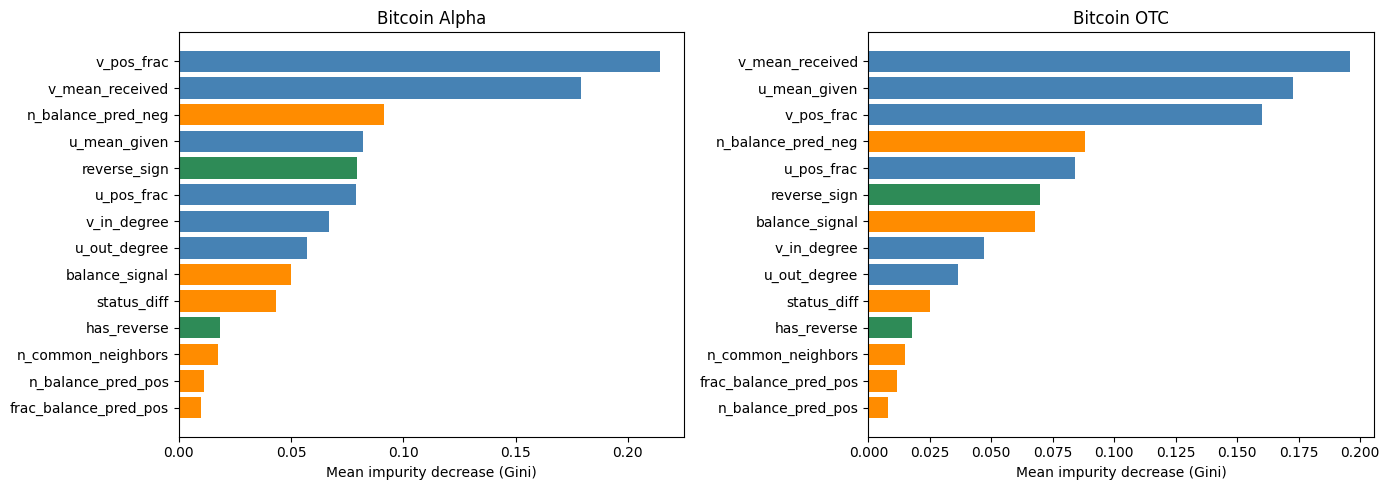

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (roc_auc_score, f1_score, classification_report,
                             confusion_matrix)
import os # Import the os module

RANDOM_STATE = 42

PARAM_GRID = {
    'n_estimators':     [300, 500],
    'max_depth':        [None, 10, 20],
    'min_samples_leaf': [1, 5],
    'max_features':     ['sqrt'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def train_and_evaluate_rf(X_train, y_train, X_test, y_test, name):
    """
    Train a Random Forest with CV-selected hyperparameters on (X_train, y_train),
    then evaluate on (X_test, y_test). Labels are {-1, +1}; the negative class
    (distrust, y = -1) is the minority class of interest.
    """
    print(f'\n{"=" * 60}')
    print(f'  {name}')
    print(f'{"=" * 60}')

    base = RandomForestClassifier(
        class_weight='balanced',   # offsets the ~90/10 imbalance
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )

    grid = GridSearchCV(
        estimator=base,
        param_grid=PARAM_GRID,
        scoring='roc_auc',         # threshold-independent, robust to imbalance
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=0,
    )

    grid.fit(X_train, y_train)
    model = grid.best_estimator_

    print(f'Best CV params      : {grid.best_params_}')
    print(f'Best CV AUC-ROC     : {grid.best_score_:.4f}')

    # Test-set evaluation
    # predict_proba columns follow model.classes_; pick the probability for class +1
    proba_pos = model.predict_proba(X_test)[:, list(model.classes_).index(1)]
    y_pred = model.predict(X_test)

    test_auc = roc_auc_score(y_test, proba_pos)
    test_f1_neg = f1_score(y_test, y_pred, pos_label=-1)
    test_f1_pos = f1_score(y_test, y_pred, pos_label=1)

    print(f'\nTest AUC-ROC        : {test_auc:.4f}')
    print(f'Test F1 (negative)  : {test_f1_neg:.4f}')
    print(f'Test F1 (positive)  : {test_f1_pos:.4f}')

    print('\nClassification report:')
    print(classification_report(y_test, y_pred, digits=4,
                                target_names=['distrust (-1)', 'trust (+1)']))

    print('Confusion matrix (rows = true, cols = pred), order [-1, +1]:')
    print(confusion_matrix(y_test, y_pred, labels=[-1, 1]))

    # Feature importances, sorted
    importances = pd.Series(model.feature_importances_,
                            index=X_train.columns).sort_values(ascending=False)
    print('\nTop feature importances:')
    print(importances.round(4).to_string())

    return {
        'name': name,
        'model': model,
        'best_params': grid.best_params_,
        'cv_auc': grid.best_score_,
        'test_auc': test_auc,
        'test_f1_neg': test_f1_neg,
        'test_f1_pos': test_f1_pos,
        'importances': importances,
    }


# Train on both datasets
results_alpha = train_and_evaluate_rf(
    X_train_alpha, y_train_alpha, X_test_alpha, y_test_alpha, 'Bitcoin Alpha'
)
results_otc = train_and_evaluate_rf(
    X_train_otc, y_train_otc, X_test_otc, y_test_otc, 'Bitcoin OTC'
)

# Unified summary table (matches the format you'll want in the final report)
print(f'\n{"=" * 60}')
print('  Summary')
print(f'{"=" * 60}')
summary = pd.DataFrame([
    {'Dataset': r['name'],
     'CV AUC-ROC':       round(r['cv_auc'], 4),
     'Test AUC-ROC':     round(r['test_auc'], 4),
     'Test F1 (neg)':    round(r['test_f1_neg'], 4),
     'Test F1 (pos)':    round(r['test_f1_pos'], 4)}
    for r in (results_alpha, results_otc)
])
print(summary.to_string(index=False))

# Create the 'figures' directory if it doesn't exist
output_dir = 'figures'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, res in zip(axes, [results_alpha, results_otc]):
    imp = res['importances']
    colors = ['steelblue' if f in FEATURE_COLS else
              'darkorange' if f in BALANCE_FEATURE_COLS + STATUS_FEATURE_COLS else
              'seagreen' for f in imp.index]
    ax.barh(imp.index[::-1], imp.values[::-1], color=colors[::-1])
    ax.set_title(res['name'])
    ax.set_xlabel('Mean impurity decrease (Gini)')
plt.tight_layout()
plt.savefig('figures/feature_importances.png', dpi=150)

##Ablation Study

In the following section we will run the ablation study that will help us fully answer **Research Question 1**


###Purpose
The ablation study wants to **quantify the marginal contribution of each feature pillar** to the model's predictive performance. We do this by retraining the RF four times, each time removing one theoretical feature group:
1. full model: already computed, all pillars are combined;
2. without Balance Theory features: remove
`BALANCE_FEATURE_COLS`;
3. without Status Theory features: remove `STATUS_FEATURE_COLS`
4. without Reciprocity features: remove `RECIPROCITY_FEATURE_COLS`;
5. local node behaviour features only: keeps `FEATURE_COLS` only (degree and means); no sociological or reciprocity features at all.

The drop in AUC-ROC from starting condition (1) to each ablated condition directly measures how much that pillar contributes to predictive performance.

###Hyperparameter strategy
Regarding the hyperparameter choosen, we reuse the **best hyperparameters** found by grid search on the full model (stored in `results_alpha['best_params']` and `results_otc['best_params']`).

This choice is intentional: if we re-ran grid search for each condition, any difference in AUC could be due to a different hyperparameter setting rather than the removed features. **Fixing params isolates the feature contribution cleanly**.

### Feature column groups
The feature columns we are going to use for the analysis are the following:

1. `FEATURE_COLS`: encapsulate the loacal node behaviour (degrees, means, positive fractions)
2. `BALANCE_FEATURE_COLS`: Balance Theory (common neighbours, balance signal);
3. `STATUS_FEATURE_COLS`: Status Theory (`status_diff`);
4. `RECIPROCITY_FEATURE_COLS`: Reciprocity (`has_reverse`, `reverse_sign`);
5. `ALL_FEATURE_COLS`: all of the above concatenated.

('Full model', ['u_out_degree', 'u_mean_given', 'u_pos_frac', 'v_in_degree', 'v_mean_received', 'v_pos_frac', 'n_common_neighbors', 'n_balance_pred_pos', 'n_balance_pred_neg', 'frac_balance_pred_pos', 'balance_signal', 'status_diff', 'has_reverse', 'reverse_sign'])

  Ablation Study — Bitcoin Alpha
  Full model                 AUC=0.8665  F1(neg)=0.4924  F1(pos)=0.9064
  w/o Balance Theory         AUC=0.8605  F1(neg)=0.4876  F1(pos)=0.8979
  w/o Status Theory          AUC=0.8715  F1(neg)=0.5216  F1(pos)=0.9072
  w/o Reciprocity            AUC=0.8344  F1(neg)=0.4605  F1(pos)=0.9075
  Local node behavior        AUC=0.8340  F1(neg)=0.4603  F1(pos)=0.8921

  Ablation Study — Bitcoin OTC
  Full model                 AUC=0.9106  F1(neg)=0.6412  F1(pos)=0.9191
  w/o Balance Theory         AUC=0.8932  F1(neg)=0.5809  F1(pos)=0.8895
  w/o Status Theory          AUC=0.9098  F1(neg)=0.6394  F1(pos)=0.9178
  w/o Reciprocity            AUC=0.8868  F1(neg)=0.6097  F1(pos)=0.9129
  Local node behavio

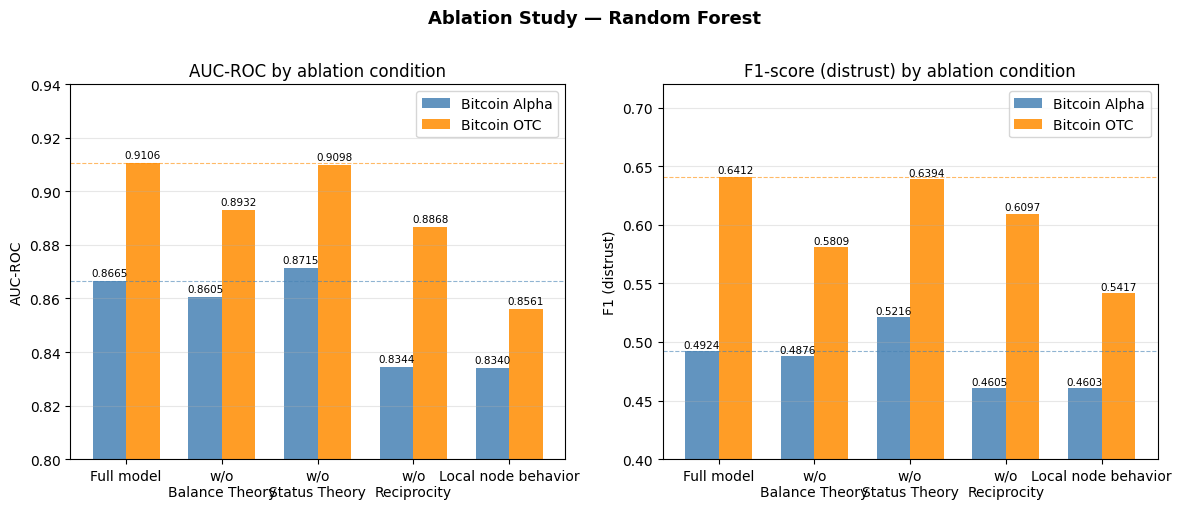

In [ ]:

#Each entry is composed by a label and a list of feature columns to use
# (the label is used only for printing, the columns are what truly matter)

ABLATION_CONDITIONS = [
    ('Full model',          ALL_FEATURE_COLS),
    ('w/o Balance Theory',  FEATURE_COLS + STATUS_FEATURE_COLS + RECIPROCITY_FEATURE_COLS),
    ('w/o Status Theory',   FEATURE_COLS + BALANCE_FEATURE_COLS + RECIPROCITY_FEATURE_COLS),
    ('w/o Reciprocity',   FEATURE_COLS + BALANCE_FEATURE_COLS + STATUS_FEATURE_COLS),
    ('Local node behavior', FEATURE_COLS),
]
print(('Full model', ALL_FEATURE_COLS))


def run_ablation(X_train, y_train, X_test, y_test, best_params, dataset_name):
    """
    Train the Random forest under each ablation condition defined above. Returns a DataFrame with the results.

    Parameters used:
      X_train:      pd.DataFrame of the full training feature matrxi (all columns)
      y_train:      np.ndarray of the full training labels ({-1, +1})
      X_test:       pd.DataFrame of the full test feature matrix (all columns)
      y_test:       np.ndarray of the full test labels ({-1, +1})
      best_params:  dict of the hyperparameters from the full-model grid search
      dataset_name: str with the name of the dataset (for printing)
    """
    print(f'\n{"=" * 60}')
    print(f'  Ablation Study — {dataset_name}')
    print(f'{"=" * 60}')

    rows = []
    for condition_name, cols in ABLATION_CONDITIONS:

        # Instantiate a fresh RF with the fixed best hyperparameters.
        model = RandomForestClassifier(
            **best_params,
            class_weight='balanced', # compensate for the ~90/10 class imbalance
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )

        # Train using only the feature columns for this condition
        # X_train[cols] selects the relevant subset of the full feature matrix
        model.fit(X_train[cols], y_train)

        # predicts class probabilities on the test set.
        # we need probability assigned to class +1 to compute the AUC-ROC, which is
        # threshold-independent and robust to the class imbalance
        proba_pos = model.predict_proba(X_test[cols])[:, list(model.classes_).index(1)]
        y_pred    = model.predict(X_test[cols])


        # COMPUTATION OF METRICS
        # AUC-ROC is the primary metric and measure how well the model ranks positive edges
        # above negative ones, regardless of decision threshold
        auc    = roc_auc_score(y_test, proba_pos)

        # F1 on the distrust class directly measures how well the model detects
        # fraudulent interactions.
        f1_neg = f1_score(y_test, y_pred, pos_label=-1)

        # F1 on the trust class is reported for completeness but it is less important
        # than the previous one given that the large majority of edges is positive in both datasets
        f1_pos = f1_score(y_test, y_pred, pos_label=1)

        rows.append({
            'Condition':     condition_name,
            'AUC-ROC':       round(auc,    4),
            'F1 (distrust)': round(f1_neg, 4),
            'F1 (trust)':    round(f1_pos, 4),
        })
        print(f'  {condition_name:<25}  AUC={auc:.4f}  F1(neg)={f1_neg:.4f}  F1(pos)={f1_pos:.4f}')

    return pd.DataFrame(rows)


# the ablation study is ran on both datasets

ablation_alpha = run_ablation(
    X_train_alpha, y_train_alpha,
    X_test_alpha,  y_test_alpha,
    results_alpha['best_params'],
    'Bitcoin Alpha',
)

ablation_otc = run_ablation(
    X_train_otc, y_train_otc,
    X_test_otc,  y_test_otc,
    results_otc['best_params'],
    'Bitcoin OTC',
)

print('\n── Ablation summary: Bitcoin Alpha ──')
print(ablation_alpha.to_string(index=False))
print('\n── Ablation summary: Bitcoin OTC ──')
print(ablation_otc.to_string(index=False))


#Plotting a graph

conditions = ablation_alpha['Condition'].tolist()
conditions_wrapped = [c.replace('w/o ', 'w/o\n') for c in conditions]  # wrap long labels

auc_alpha = ablation_alpha['AUC-ROC'].tolist()
auc_otc   = ablation_otc['AUC-ROC'].tolist()
f1_alpha  = ablation_alpha['F1 (distrust)'].tolist()
f1_otc    = ablation_otc['F1 (distrust)'].tolist()

x     = np.arange(len(conditions))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, vals_alpha, vals_otc, ylabel, title, ymin, ymax in [
    (axes[0], auc_alpha, auc_otc, 'AUC-ROC',      'AUC-ROC by ablation condition',             0.80, 0.94),
    (axes[1], f1_alpha,  f1_otc,  'F1 (distrust)', 'F1-score (distrust) by ablation condition', 0.40, 0.72),
]:
    b_alpha = ax.bar(x - width/2, vals_alpha, width, label='Bitcoin Alpha', color='steelblue',  alpha=0.85)
    b_otc   = ax.bar(x + width/2, vals_otc,   width, label='Bitcoin OTC',   color='darkorange', alpha=0.85)

    # Dashed reference lines at full-model performance so the drop is immediately visible
    ax.axhline(vals_alpha[0], color='steelblue',  linestyle='--', linewidth=0.8, alpha=0.6)
    ax.axhline(vals_otc[0],   color='darkorange', linestyle='--', linewidth=0.8, alpha=0.6)

    # Annotate each bar with its numeric value
    for bar in b_alpha:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=7.5)
    for bar in b_otc:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=7.5)

    ax.set_title(title, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(conditions_wrapped, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_ylim(ymin, ymax)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Ablation Study — Random Forest', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

##Cross-dataset validation

The second **Research Question** that leads our work is the **Cross-Dataset validation**. So we evaluate whether trust dynamics learned on one platform transfer to the other WITHOUT retraining. Two directions are tested:


*   OTC -> Alpha: train on OTC (larger dataset), evaluate on Alpha (smaller)
*   Alpha -> OTC: train on Alpha and evaluate on OTC

The models, at this stage, are already trained above (`results_otc` and `results_alpha`). We reuse their best estimators directly, so no fittings happens in the cross-validation step.

Our prediction is that: if AUC-ROC reamins well above 0.5 in both directions, the learned trust patterns reflect universal properties of web-of-trust dynamics rather than platform-specific noise, answering RQ2 positively.




  Cross-Dataset Generalisation (RQ2)
  OTC → Alpha           AUC=0.8835  F1(neg)=0.5608  F1(pos)=0.9309
  Alpha → OTC           AUC=0.8779  F1(neg)=0.5404  F1(pos)=0.8743

── Cross-dataset summary ──
  Direction  AUC-ROC  F1 (distrust)  F1 (trust)
OTC → Alpha   0.8835         0.5608      0.9309
Alpha → OTC   0.8779         0.5404      0.8743

── In-dataset reference ──
  Alpha (in-dataset)   AUC=0.8665  F1(neg)=0.4924  F1(pos)=0.9064
  OTC   (in-dataset)   AUC=0.9106  F1(neg)=0.6412  F1(pos)=0.9191


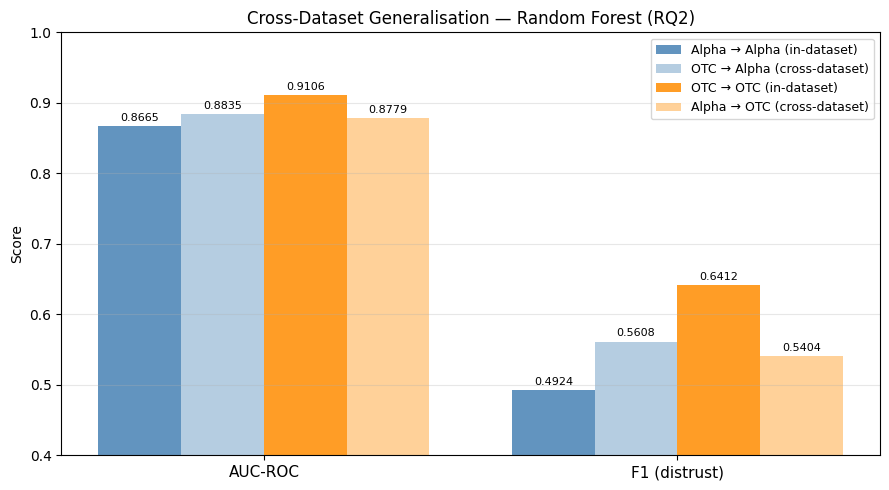

In [ ]:
def cross_evaluate(source_results, X_test_target, y_test_target, direction):
    """
    Apply a trained model to a test set from a different dataset.

    Parameters
    ----------
    source_results:   dict returned by train_and_evaluate_rf (contains 'model')
    X_test_target:    pd.DataFrame  test features from the target dataset
    y_test_target:    np.ndarray    test labels from the target dataset
    direction:        str           label for printing (e.g. 'OTC → Alpha')
    """
    model = source_results['model']

    # Predict probabilities for class +1 on the target test set
    proba_pos = model.predict_proba(X_test_target)[:, list(model.classes_).index(1)]
    y_pred    = model.predict(X_test_target)

    auc    = roc_auc_score(y_test_target, proba_pos)
    f1_neg = f1_score(y_test_target, y_pred, pos_label=-1)
    f1_pos = f1_score(y_test_target, y_pred, pos_label=1)

    print(f'  {direction:<20}  AUC={auc:.4f}  F1(neg)={f1_neg:.4f}  F1(pos)={f1_pos:.4f}')

    return {'Direction': direction, 'AUC-ROC': round(auc, 4),
            'F1 (distrust)': round(f1_neg, 4), 'F1 (trust)': round(f1_pos, 4)}


print(f'\n{"=" * 60}')
print('  Cross-Dataset Generalisation (RQ2)')
print(f'{"=" * 60}')

cross_results = pd.DataFrame([
    # Train on OTC, test on Alpha test set
    cross_evaluate(results_otc,   X_test_alpha, y_test_alpha, 'OTC → Alpha'),
    # Train on Alpha, test on OTC test set
    cross_evaluate(results_alpha, X_test_otc,   y_test_otc,   'Alpha → OTC'),
])

print('\n── Cross-dataset summary ──')
print(cross_results.to_string(index=False))

# Printing side by side makes the generalisation gap immediately visible.
print('\n── In-dataset reference ──')
print(f"  Alpha (in-dataset)   AUC={results_alpha['test_auc']:.4f}  "
      f"F1(neg)={results_alpha['test_f1_neg']:.4f}  F1(pos)={results_alpha['test_f1_pos']:.4f}")
print(f"  OTC   (in-dataset)   AUC={results_otc['test_auc']:.4f}  "
      f"F1(neg)={results_otc['test_f1_neg']:.4f}  F1(pos)={results_otc['test_f1_pos']:.4f}")

# Cross-Dataset Plot
# Compares in-dataset vs cross-dataset performance side by side so the
# generalisation gap is immediately visible.

labels    = ['AUC-ROC', 'F1 (distrust)']
width     = 0.2
x         = np.arange(len(labels))

# In-dataset scores (from the main RF evaluation above)
in_alpha  = [results_alpha['test_auc'], results_alpha['test_f1_neg']]
in_otc    = [results_otc['test_auc'],   results_otc['test_f1_neg']]

# Cross-dataset scores (from cross_results DataFrame)
cross_otc_to_alpha = [
    cross_results.loc[cross_results['Direction'] == 'OTC → Alpha', 'AUC-ROC'].values[0],
    cross_results.loc[cross_results['Direction'] == 'OTC → Alpha', 'F1 (distrust)'].values[0],
]
cross_alpha_to_otc = [
    cross_results.loc[cross_results['Direction'] == 'Alpha → OTC', 'AUC-ROC'].values[0],
    cross_results.loc[cross_results['Direction'] == 'Alpha → OTC', 'F1 (distrust)'].values[0],
]

fig, ax = plt.subplots(figsize=(9, 5))

b1 = ax.bar(x - 1.5*width, in_alpha,            width, label='Alpha → Alpha (in-dataset)', color='steelblue',   alpha=0.85)
b2 = ax.bar(x - 0.5*width, cross_otc_to_alpha,  width, label='OTC → Alpha (cross-dataset)', color='steelblue',  alpha=0.40)
b3 = ax.bar(x + 0.5*width, in_otc,              width, label='OTC → OTC (in-dataset)',   color='darkorange',    alpha=0.85)
b4 = ax.bar(x + 1.5*width, cross_alpha_to_otc,  width, label='Alpha → OTC (cross-dataset)', color='darkorange', alpha=0.40)

# Annotate each bar
for bar in [b1, b2, b3, b4]:
    for rect in bar:
        ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.005,
                f'{rect.get_height():.4f}', ha='center', va='bottom', fontsize=8)

ax.set_title('Cross-Dataset Generalisation — Random Forest (RQ2)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0.40, 1.00)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cross_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

# SGCN

The SGCN (Derr et al., 2018) is trained on the same temporal split used for the Random Forest. Following the original paper, the directed graph is treated as undirected: each training edge u->v is inserted in both directions into the positive or negative adjacency matrix.
Node input features are the six local behaviour statistics explained before, L2-normalized and computed from training history only, nodes unseen during training are initialized to zero.

In [ ]:
!pip install torch_geometric --quiet
import torch
import numpy as np
from torch_geometric.nn import SignedGCN
from sklearn.metrics import roc_auc_score, f1_score

print(f'torch version      : {torch.__version__}')
print(f'cuda available     : {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device             : {DEVICE}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.0 MB/s eta 0:00:00
torch version      : 2.11.0+cu128
cuda available     : True
device             : cuda


In [ ]:
def build_sgcn_data_undirected(train_df, test_df):
    """
    Build SGCN data with undirected graph, matching Derr et al. 2018.
    Each directed edge u->v is added in both directions.
    Node features are L2-normalized local statistics from training history.
    """
    all_nodes = pd.concat([
        train_df['source'], train_df['target'],
        test_df['source'],  test_df['target'],
    ]).unique()
    node_map = {n: i for i, n in enumerate(all_nodes)}
    N = len(node_map)

    # Build node features from training history only
    history = LocalNodeHistory()
    for _, row in train_df.iterrows():
        history.update(row['source'], row['target'], row['rating'])

    x = torch.zeros(N, 6, dtype=torch.float)
    for node, idx in node_map.items():
        od  = history.out_degree[node]
        id_ = history.in_degree[node]
        x[idx] = torch.tensor([
            float(od),
            history.out_rating_sum[node] / od  if od  > 0 else 0.0,
            history.out_pos_count[node]  / od  if od  > 0 else 0.0,
            float(id_),
            history.in_rating_sum[node]  / id_ if id_ > 0 else 0.0,
            history.in_pos_count[node]   / id_ if id_ > 0 else 0.0,
        ])

    # L2 normalize each node feature vector
    norms = x.norm(dim=1, keepdim=True).clamp(min=1e-8)
    x = x / norms

    def to_undirected_tensor(df, sign_val):
        mask = df['sign'] == sign_val
        src  = [node_map[s] for s in df.loc[mask, 'source']]
        dst  = [node_map[t] for t in df.loc[mask, 'target']]
        # add both directions
        fwd  = torch.tensor([src, dst], dtype=torch.long)
        bwd  = torch.tensor([dst, src], dtype=torch.long)
        return torch.cat([fwd, bwd], dim=1)

    return (
        node_map, x,
        to_undirected_tensor(train_df,  1),
        to_undirected_tensor(train_df, -1),
        to_undirected_tensor(test_df,   1),
        to_undirected_tensor(test_df,  -1),
    )


(node_map_alpha, x_alpha,
 pos_train_alpha, neg_train_alpha,
 pos_test_alpha,  neg_test_alpha) = build_sgcn_data_undirected(alpha_train, alpha_test)

(node_map_otc, x_otc,
 pos_train_otc, neg_train_otc,
 pos_test_otc,  neg_test_otc) = build_sgcn_data_undirected(otc_train, otc_test)

print(f'Alpha: {x_alpha.shape[0]} nodes | '
      f'train pos={pos_train_alpha.shape[1]} neg={neg_train_alpha.shape[1]} | '
      f'test pos={pos_test_alpha.shape[1]} neg={neg_test_alpha.shape[1]}')
print(f'OTC:   {x_otc.shape[0]} nodes | '
      f'train pos={pos_train_otc.shape[1]} neg={neg_train_otc.shape[1]} | '
      f'test pos={pos_test_otc.shape[1]} neg={neg_test_otc.shape[1]}')

Alpha: 3783 nodes | train pos=36858 neg=1838 | test pos=8442 neg=1234
OTC:   5881 nodes | train pos=52010 neg=4936 | test pos=12048 neg=2190


Sign prediction for a test edge (u, v) is determined by the sign of the dot product between the learned embeddings z_u · z_v. A positive dot product predicts trust (+1), a negative one predicts distrust (−1). The model is optimised with Adam for 300 epochs and evaluated every 50 epochs; the checkpoint with the highest AUC on the test set is retained.

In [ ]:
def evaluate_sgcn(z, pos_test, neg_test):
    """
    Evaluate node embeddings on test edges.
    Score = dot product of endpoint embeddings.
    Metrics match the RF evaluation: AUC-ROC and F1 on distrust class.
    """
    with torch.no_grad():
        pos_scores = (z[pos_test[0]] * z[pos_test[1]]).sum(dim=-1).cpu().numpy() #dot product
        neg_scores = (z[neg_test[0]] * z[neg_test[1]]).sum(dim=-1).cpu().numpy() #dot product

    scores = np.concatenate([pos_scores, neg_scores])
    y_true = np.concatenate([
        np.ones(len(pos_scores)),
        -np.ones(len(neg_scores)),
    ])

    auc    = roc_auc_score((y_true == 1).astype(int), scores)

    #evaluation of the dot product
    y_pred = np.where(scores > 0, 1, -1)
    f1_neg = f1_score(y_true, y_pred, pos_label=-1)
    f1_pos = f1_score(y_true, y_pred, pos_label=1)
    return auc, f1_neg, f1_pos


def train_sgcn(x, pos_train, neg_train, pos_test, neg_test,
               name, hidden=64, num_layers=2, epochs=300, lr=0.01):
    """
    Train SignedGCN and return best embeddings and metrics.
    Graph is built from training edges only.
    """
    torch.manual_seed(42)
    np.random.seed(42)

    x         = x.to(DEVICE)
    pos_train = pos_train.to(DEVICE)
    neg_train = neg_train.to(DEVICE)
    pos_test  = pos_test.to(DEVICE)
    neg_test  = neg_test.to(DEVICE)

    model     = SignedGCN(x.shape[1], hidden,
                          num_layers=num_layers, lamb=5).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=lr, weight_decay=5e-4)

    best_auc     = 0.0
    best_metrics = (0.0, 0.0, 0.0)
    best_z       = None

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        z    = model(x, pos_train, neg_train)
        loss = model.loss(z, pos_train, neg_train)
        loss.backward()
        optimizer.step()

        if epoch % 50 == 0:
            model.eval()
            with torch.no_grad():
                z_eval = model(x, pos_train, neg_train)
            auc, f1_neg, f1_pos = evaluate_sgcn(z_eval, pos_test, neg_test)
            print(f'  [{name}] epoch {epoch:3d}  loss={loss.item():.4f}  '
                  f'AUC={auc:.4f}  F1(neg)={f1_neg:.4f}')
            if auc > best_auc:
                best_auc     = auc
                best_metrics = (auc, f1_neg, f1_pos)
                best_z       = z_eval.cpu()

    return best_z, best_metrics


print('Training SGCN — Bitcoin Alpha')
z_alpha, metrics_alpha = train_sgcn(
    x_alpha, pos_train_alpha, neg_train_alpha,
    pos_test_alpha, neg_test_alpha, 'Alpha',
)

print('\nTraining SGCN — Bitcoin OTC')
z_otc, metrics_otc = train_sgcn(
    x_otc, pos_train_otc, neg_train_otc,
    pos_test_otc, neg_test_otc, 'OTC',
)

Training SGCN — Bitcoin Alpha
  [Alpha] epoch  50  loss=1.0172  AUC=0.5302  F1(neg)=0.0000
  [Alpha] epoch 100  loss=0.8129  AUC=0.5156  F1(neg)=0.0000
  [Alpha] epoch 150  loss=0.6993  AUC=0.5299  F1(neg)=0.0000
  [Alpha] epoch 200  loss=0.6320  AUC=0.5356  F1(neg)=0.0000
  [Alpha] epoch 250  loss=0.5873  AUC=0.5312  F1(neg)=0.0000
  [Alpha] epoch 300  loss=0.5582  AUC=0.5327  F1(neg)=0.0000

Training SGCN — Bitcoin OTC
  [OTC] epoch  50  loss=0.9418  AUC=0.6447  F1(neg)=0.0000
  [OTC] epoch 100  loss=0.7120  AUC=0.6548  F1(neg)=0.0000
  [OTC] epoch 150  loss=0.6039  AUC=0.6413  F1(neg)=0.0000
  [OTC] epoch 200  loss=0.5497  AUC=0.6388  F1(neg)=0.0000
  [OTC] epoch 250  loss=0.5147  AUC=0.6357  F1(neg)=0.0000
  [OTC] epoch 300  loss=0.4971  AUC=0.6354  F1(neg)=0.0000


The SGCN collapses to predicting trust for every edge on both datasets (F1− = 0), despite AUC scores marginally above 0.5. This is a direct consequence of severe class imbalance: the positive aggregation channel sees roughly 18× more edges than the negative channel on Alpha and 11× more on OTC, preventing the negative channel from learning embeddings that consistently separate distrust edges from trust ones.

In [ ]:
comparison = pd.DataFrame([
    {
        'Model':   'Random Forest',
        'Dataset': 'Bitcoin Alpha',
        'AUC-ROC': results_alpha['test_auc'],
        'F1 (distrust)': results_alpha['test_f1_neg'],
        'F1 (trust)':    results_alpha['test_f1_pos'],
    },
    {
        'Model':   'SGCN',
        'Dataset': 'Bitcoin Alpha',
        'AUC-ROC': round(metrics_alpha[0], 4),
        'F1 (distrust)': round(metrics_alpha[1], 4),
        'F1 (trust)':    round(metrics_alpha[2], 4),
    },
    {
        'Model':   'Random Forest',
        'Dataset': 'Bitcoin OTC',
        'AUC-ROC': results_otc['test_auc'],
        'F1 (distrust)': results_otc['test_f1_neg'],
        'F1 (trust)':    results_otc['test_f1_pos'],
    },
    {
        'Model':   'SGCN',
        'Dataset': 'Bitcoin OTC',
        'AUC-ROC': round(metrics_otc[0], 4),
        'F1 (distrust)': round(metrics_otc[1], 4),
        'F1 (trust)':    round(metrics_otc[2], 4),
    },
])

print('RF vs SGCN comparison:')
print(comparison.to_string(index=False))

RF vs SGCN comparison:
        Model       Dataset  AUC-ROC  F1 (distrust)  F1 (trust)
Random Forest Bitcoin Alpha 0.866465       0.492369    0.906353
         SGCN Bitcoin Alpha 0.535600       0.000000    0.931900
Random Forest   Bitcoin OTC 0.910589       0.641221    0.919091
         SGCN   Bitcoin OTC 0.654800       0.000000    0.916700
